In [ ]:
# 📘 BERT-based Sentiment Analysis
1️⃣ #Problem Definition

#Objective:
#To build a sentiment classification model that predicts Negative, Neutral, or Positive sentiment from Amazon product reviews using a pretrained BERT model, and to compare its performance with traditional machine learning approaches.

#Type:

#Supervised learning

#Multi-class text classification#

2️⃣# Dataset Description

#The dataset contains Amazon product reviews with the following relevant columns:

#Column	Description
#Text	Full customer review text
#Score	Rating (1–5)
#Sentiment (derived)	Negative / Neutral / Positive

#Sentiment Mapping:

#Score ≤ 2 → Negative

#Score = 3 → Neutral

#Score ≥ 4 → Positive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Environment Setup

In [5]:
!pip install transformers datasets torch accelerate scikit-learn matplotlib seaborn


In [6]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [7]:
# Data Loading
df = pd.read_csv("/content/drive/MyDrive/Dataset/Reviews.csv")
df = df[['Text', 'Score']].dropna()

df.head()


,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [8]:
df['Score'].value_counts()


,count
Score,
5,363122
4,80655
1,52268
3,42640
2,29769


In [9]:
# Sample for faster training
df = df.sample(50000, random_state=42)


In [10]:
# Label encoding
def map_sentiment(score):
    if score <= 2:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

df['label'] = df['Score'].apply(map_sentiment)

label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}


In [11]:
# train_test_split
train_df, test_df = train_test_split(
    df[['Text', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)


In [12]:
# Reset index
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)


In [13]:
# Validation split
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df['label']
)


In [14]:
# Bert Tokenization
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
MAX_LEN = 128



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [15]:
# Tokenize train and test separately
train_encodings = tokenizer(
    train_df['Text'].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

test_encodings = tokenizer(
    test_df['Text'].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)


In [16]:
MAX_LEN = 128

def tokenize(batch):
    return tokenizer(
        batch["Text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )



In [17]:
print(train_df.columns)


Index(['Text', 'label'], dtype='object')


In [18]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

# -------------------------------
# Tokenize
# -------------------------------
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

# -------------------------------
# Remove unused text column
# -------------------------------
train_dataset = train_dataset.remove_columns(["Text"])
val_dataset   = val_dataset.remove_columns(["Text"])
test_dataset  = test_dataset.remove_columns(["Text"])

# -------------------------------
# Set PyTorch tensor format
# -------------------------------
columns = ["input_ids", "attention_mask", "label"]

train_dataset.set_format(type="torch", columns=columns)
val_dataset.set_format(type="torch", columns=columns)
test_dataset.set_format(type="torch", columns=columns)


Map:   0%|          | 0/36000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [23]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3,
    output_attentions=False,
    output_hidden_states=False
)





Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [2]:
pip install -U transformers accelerate datasets


In [1]:
import transformers
print(transformers.__version__)


4.57.6


In [19]:
import torch
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)


cuda


In [20]:
# Training Setups
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_output",
    eval_strategy="epoch",          # ✅ NEW name
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)



In [21]:
# Model Training
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }



In [24]:
# trainer
# -------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # validation for monitoring
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# -------------------------------
# 2️⃣ Train
# -------------------------------
trainer.train()


/tmp/ipython-input-2106091435.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.276000,0.392464,0.885250,0.872547
2,0.255800,0.448178,0.884500,0.869286
3,0.168000,0.448785,0.897250,0.893458


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.276000,0.392464,0.885250,0.872547
2,0.255800,0.448178,0.884500,0.869286
3,0.168000,0.448785,0.897250,0.893458
4,0.073300,0.565198,0.894250,0.892962
5,0.077800,0.682849,0.891750,0.891256


TrainOutput(global_step=22500, training_loss=0.19825708950890436, metrics={'train_runtime': 4605.2525, 'train_samples_per_second': 39.086, 'train_steps_per_second': 4.886, 'total_flos': 1.184010379776e+16, 'train_loss': 0.19825708950890436, 'epoch': 5.0})

In [25]:
# Evaluate on validation
val_metrics = trainer.evaluate(val_dataset)
print("Validation Metrics:", val_metrics)


Validation Metrics: {'eval_loss': 0.44878461956977844, 'eval_accuracy': 0.89725, 'eval_f1': 0.8934581975283656, 'eval_runtime': 26.9853, 'eval_samples_per_second': 148.229, 'eval_steps_per_second': 18.529, 'epoch': 5.0}


In [26]:
# Evaluate on test set
test_metrics = trainer.evaluate(test_dataset)
print("Test Metrics:", test_metrics)

Test Metrics: {'eval_loss': 0.47471392154693604, 'eval_accuracy': 0.8889, 'eval_f1': 0.8853276875400584, 'eval_runtime': 70.943, 'eval_samples_per_second': 140.958, 'eval_steps_per_second': 17.62, 'epoch': 5.0}


# Training vs Validation Loss

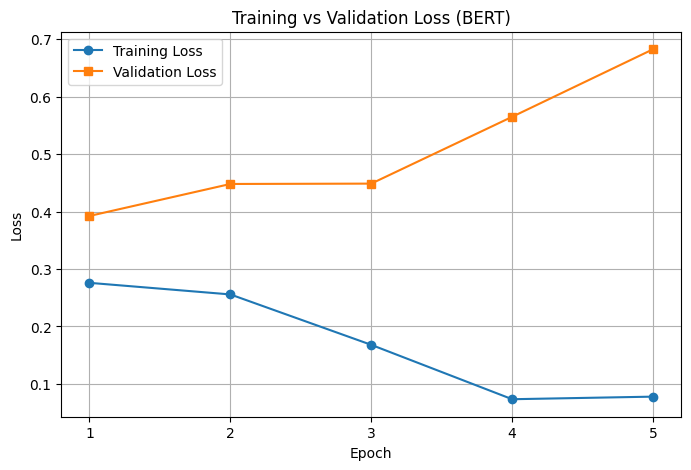

In [27]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]

training_loss = [0.2760, 0.2558, 0.1680, 0.0733, 0.0778]
validation_loss = [0.392464, 0.448178, 0.448785, 0.565198, 0.682849]

plt.figure(figsize=(8, 5))

plt.plot(epochs, training_loss, marker='o', label="Training Loss")
plt.plot(epochs, validation_loss, marker='s', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (BERT)")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()



In [28]:
# Confusion Matrix for BERT fine tuning
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions
predictions = trainer.predict(test_dataset)

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)


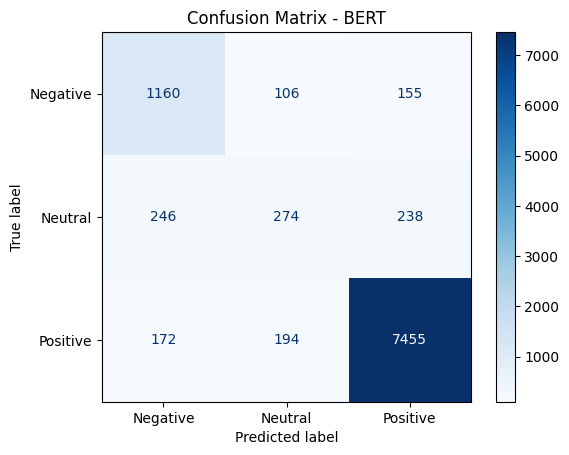

In [30]:
labels = ["Negative", "Neutral", "Positive"]

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - BERT")
plt.show()


In [33]:
# New Review Prediction From BERT
import torch
import numpy as np

id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}

def predict_sentiment_bert(text):
    device = next(model.parameters()).device  # detect model device

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    #  Move inputs to same device as model
    inputs = {key: val.to(device) for key, val in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    predicted_class = np.argmax(probs)

    return {
        "Predicted Sentiment": id2label[predicted_class],
        "Confidence Scores": {
            "Negative": round(float(probs[0]), 4),
            "Neutral": round(float(probs[1]), 4),
            "Positive": round(float(probs[2]), 4)
        }
    }



In [34]:
user_review = "The product quality is excellent and delivery was fast."

result = predict_sentiment_bert(user_review)
print(result)


{'Predicted Sentiment': 'Positive', 'Confidence Scores': {'Negative': 0.0001, 'Neutral': 0.0018, 'Positive': 0.9981}}


# Visually Compare all Logistic regression and BERT model

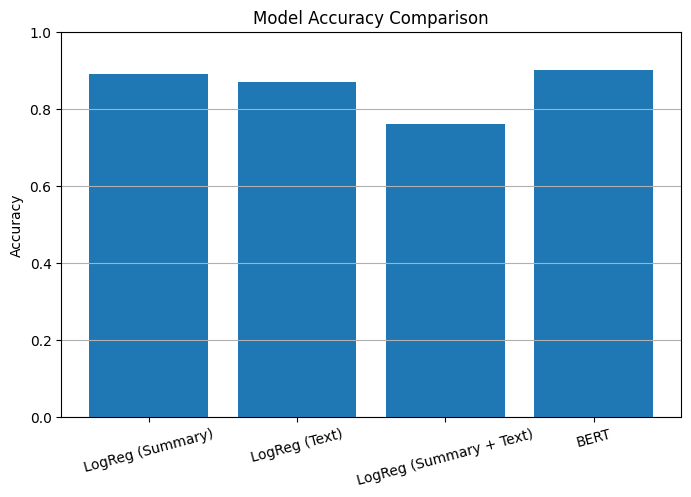

In [35]:
import matplotlib.pyplot as plt

models = [
    "LogReg (Summary)",
    "LogReg (Text)",
    "LogReg (Summary + Text)",
    "BERT"
]

accuracies = [0.89, 0.87, 0.76, 0.90]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.grid(axis='y')

plt.show()


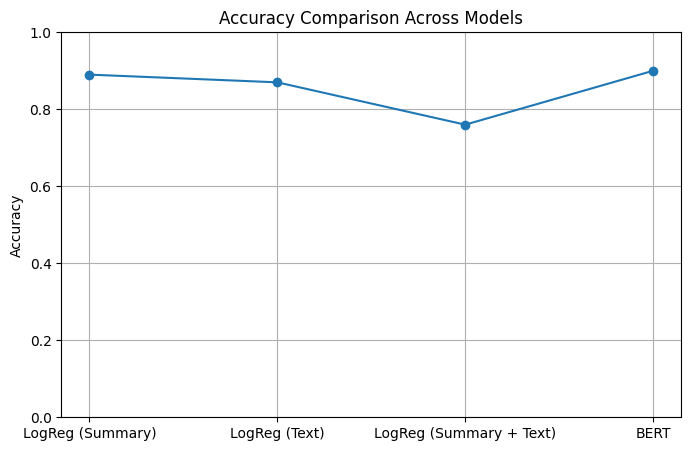

In [36]:
# Line plot for clear ranking
plt.figure(figsize=(8, 5))
plt.plot(models, accuracies, marker='o')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison Across Models")
plt.grid(True)
plt.show()


Interpretation (WRITE THIS — VERY IMPORTANT)
🔹 Key Observations

BERT achieves the highest accuracy (0.90)

Captures contextual meaning using bidirectional attention

Understands sentiment beyond keyword frequency

Logistic Regression using Summary performs well (0.89)

Summary contains concise sentiment-rich information

Less noise compared to full review text

Logistic Regression using full Text performs slightly worse (0.87)

Longer reviews introduce irrelevant details

TF-IDF treats all words equally, ignoring context

Combined Summary + Text performs worst (0.76)

Feature space becomes too large

Sparsity increases

Model suffers from noise and overfitting